In [1]:
# Assistant
# ==========================================
try:
    import missingno as msno
except ImportError:
    print("Installing missingno...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "missingno"])
    import missingno as msno

# Import other libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Loaded Successfully")
# EV PROJECT — DATA PROFILING
# ==========================================

# Install missingno if not already installed
import subprocess
import sys


Libraries Loaded Successfully



**Key changes:**
- Added a try-except block to check if `missingno` is available
- If not found, the code automatically installs it using pip
- Then imports the library after installation
- This ensures the code runs without manual intervention

**Alternative solution:** You can also run `!pip install missingno` in a separate Jupyter cell before running your main code.

In [2]:
# Load dataset

df = pd.read_csv('D:/Project-04/EV_Usage_Dataset_v2.csv')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# Dataset shape

print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

Rows and Columns:
(10939, 23)

Column Names:
Index(['user_id', 'city', 'trip_date', 'vehicle_type', 'battery_capacity_kwh',
       'battery_health_pct', 'distance_km', 'daily_trip_count',
       'charging_frequency_per_week', 'charging_type', 'charging_duration_min',
       'charging_station_distance_km', 'energy_consumed_kwh',
       'electricity_cost_per_kwh', 'weather_condition', 'traffic_density',
       'user_income_level', 'range_km_estimated', 'range_anxiety_risk',
       'vehicle_type_label', 'state', 'year', 'month'],
      dtype='object')


In [4]:
# First 5 rows

df.head()

,user_id,city,trip_date,vehicle_type,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_type,charging_duration_min,charging_station_distance_km,energy_consumed_kwh,electricity_cost_per_kwh,weather_condition,traffic_density,user_income_level,range_km_estimated,range_anxiety_risk,vehicle_type_label,state,year,month
0,0f043e7d-c3b7-4478-9566-18494d053204,Mumbai,2026-03-04,2W,3.25,78.31,34.72,2.0,7.0,public_fast,55.32,NaN,6.34,9.27,rainy,0.416,low,17.54,1.0,Two-Wheeler,Maharashtra,2026.0,3.0
1,8507eade-6ee7-4c2d-80b1-eacc566a7cb2,Chennai,2026-08-03,4W,37.14,74.38,1.00,3.0,6.0,home,348.99,3.08,NaN,7.98,NaN,0.266,low,189.43,1.0,Four-Wheeler,Tamil Nadu,2026.0,8.0
2,cad267b4-0561-490e-9d43-46b0530d9359,Hyderabad,2021-08-10,3W,7.46,94.55,7.74,2.0,3.0,public_slow,155.97,0.07,1.21,6.71,rainy,0.092,middle,40.26,0.0,Three-Wheeler,Telangana,2021.0,8.0
3,26e25157-b9fe-41ce-8d40-3fa3c0979de5,Delhi,2023-09-15,2W,2.37,93.46,66.67,3.0,5.0,public_fast,64.37,0.88,15.74,8.88,clear,0.251,middle,14.20,1.0,Two-Wheeler,Delhi,2023.0,9.0
4,9ca94273-0df4-48cb-be60-af643dc606f9,Bangalore,2023-09-28,2W,3.16,86.07,NaN,2.0,4.0,home,361.86,0.80,NaN,8.93,humid,0.166,low,18.97,0.0,Two-Wheeler,Karnataka,2023.0,9.0


In [5]:
# Last 5 rows

df.tail()

,user_id,city,trip_date,vehicle_type,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_type,charging_duration_min,charging_station_distance_km,energy_consumed_kwh,electricity_cost_per_kwh,weather_condition,traffic_density,user_income_level,range_km_estimated,range_anxiety_risk,vehicle_type_label,state,year,month
10934,8c56a176-732c-4627-9358-39793cf7816e,Pune,2019-05-04,2W,4.15,102.06,7.66,2.0,1.0,public_fast,57.76,4.73,1.13,5.63,clear,0.144,middle,24.90,0.0,Two-Wheeler,Maharashtra,2019.0,5.0
10935,26bbfb66-17f7-40f0-89dc-757e1d78c7c7,Delhi,2024-07-24,3W,8.11,81.52,34.17,5.0,5.0,home,183.47,3.38,5.48,8.06,extreme_heat,0.038,middle,41.35,1.0,Three-Wheeler,Delhi,2024.0,7.0
10936,7c49dcfe-f127-4feb-b8c7-a2fdf5009e6d,Chennai,2026-05-31,2W,2.68,82.78,11.63,1.0,5.0,public_slow,259.49,1.75,2.45,8.87,rainy,0.580,middle,NaN,1.0,Two-Wheeler,Tamil Nadu,2026.0,5.0
10937,cb71266f-d6df-4f18-9361-2ff6061e4a06,Chennai,2024-09-14,2W,3.09,84.32,20.01,2.0,3.0,home,368.45,0.90,3.39,7.68,humid,0.498,low,18.51,0.0,Two-Wheeler,Tamil Nadu,2024.0,9.0
10938,318d69a9-3d5f-403c-9c59-0351bb802cb8,Bangalore,2019-02-08,2W,NaN,98.50,7.75,2.0,2.0,public_fast,60.64,1.37,1.45,6.61,humid,0.328,middle,18.47,0.0,Two-Wheeler,Karnataka,2019.0,2.0


In [6]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10939 entries, 0 to 10938
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       10611 non-null  object 
 1   city                          10611 non-null  object 
 2   trip_date                     10611 non-null  object 
 3   vehicle_type                  10611 non-null  object 
 4   battery_capacity_kwh          10611 non-null  float64
 5   battery_health_pct            10611 non-null  float64
 6   distance_km                   10611 non-null  float64
 7   daily_trip_count              10611 non-null  float64
 8   charging_frequency_per_week   10611 non-null  float64
 9   charging_type                 10611 non-null  object 
 10  charging_duration_min         10611 non-null  float64
 11  charging_station_distance_km  10611 non-null  float64
 12  energy_consumed_kwh           10611 non-null  float64
 13  e

In [7]:
# Check duplicates

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [8]:
# Numerical summary

df.describe()

,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_duration_min,charging_station_distance_km,energy_consumed_kwh,electricity_cost_per_kwh,traffic_density,range_km_estimated,range_anxiety_risk,year,month
count,10611.000000,10611.000000,10611.000000,10611.000000,10611.000000,10611.000000,10611.000000,10611.000000,10611.000000,10611.000000,10611.000000,10611.000000,10611.000000,10611.00000
mean,11.964039,89.387064,26.337390,2.518047,3.295071,179.693753,1.987651,4.343499,7.752681,0.286929,67.400871,0.244463,2022.524173,6.54189
std,14.471872,8.560905,17.030512,0.994011,1.474161,106.722941,1.954789,2.610861,1.528471,0.160186,81.765749,0.429789,2.291700,3.43193
min,1.130000,62.060000,1.000000,1.000000,1.000000,-16.340000,0.000000,0.110000,2.380000,0.000000,6.030000,0.000000,2019.000000,1.00000
25%,2.990000,83.005000,14.880000,2.000000,2.000000,73.440000,0.590000,2.440000,6.650000,0.162000,16.710000,0.000000,2021.000000,4.00000
50%,4.270000,89.310000,25.270000,2.000000,3.000000,178.470000,1.390000,4.160000,7.760000,0.265000,25.140000,0.000000,2023.000000,7.00000
75%,8.960000,95.700000,35.720000,3.000000,4.000000,260.060000,2.750000,6.020000,8.860000,0.393000,51.410000,0.000000,2025.000000,10.00000
max,55.910000,116.950000,187.550000,6.000000,8.000000,497.270000,17.790000,19.830000,13.090000,0.902000,325.430000,1.000000,2026.000000,12.00000


In [9]:
# Categorical summary

df.describe(include='object')

,user_id,city,trip_date,vehicle_type,charging_type,weather_condition,user_income_level,vehicle_type_label,state
count,10611,10611,10611,10611,10611,10611,10611,10611,10611
unique,10611,7,2851,3,3,4,3,3,6
top,0f043e7d-c3b7-4478-9566-18494d053204,Pune,2026-10-01,2W,public_slow,extreme_heat,low,Two-Wheeler,Maharashtra
freq,1,1564,13,5329,3606,2700,4352,5329,3087


In [10]:
# Missing value summary table

missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by='Missing Percentage',
    ascending=False
)

missing_df

,Missing Values,Missing Percentage
user_id,328,2.998446
energy_consumed_kwh,328,2.998446
year,328,2.998446
state,328,2.998446
vehicle_type_label,328,2.998446
range_anxiety_risk,328,2.998446
range_km_estimated,328,2.998446
user_income_level,328,2.998446
traffic_density,328,2.998446
weather_condition,328,2.998446


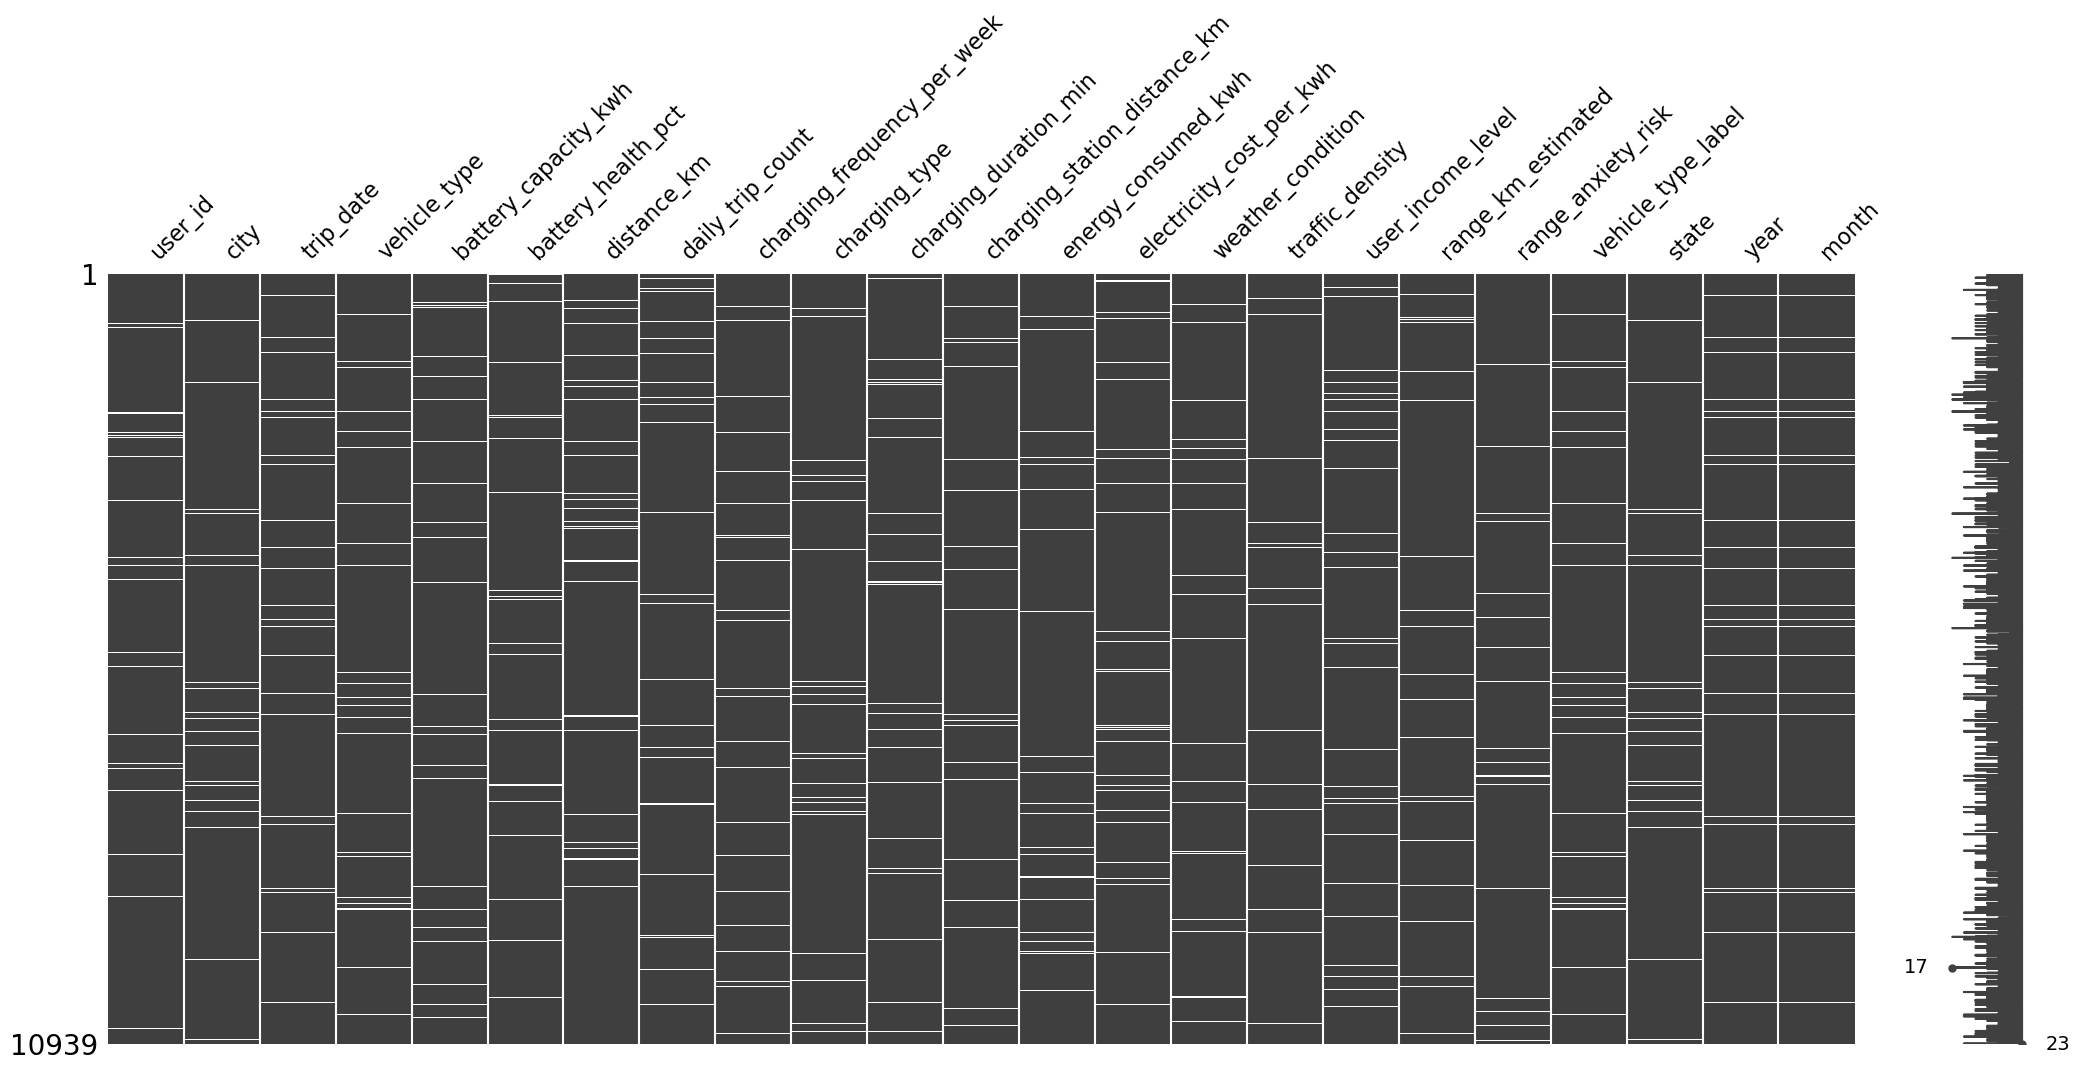

In [11]:
# Missing value matrix

msno.matrix(df)

plt.show()

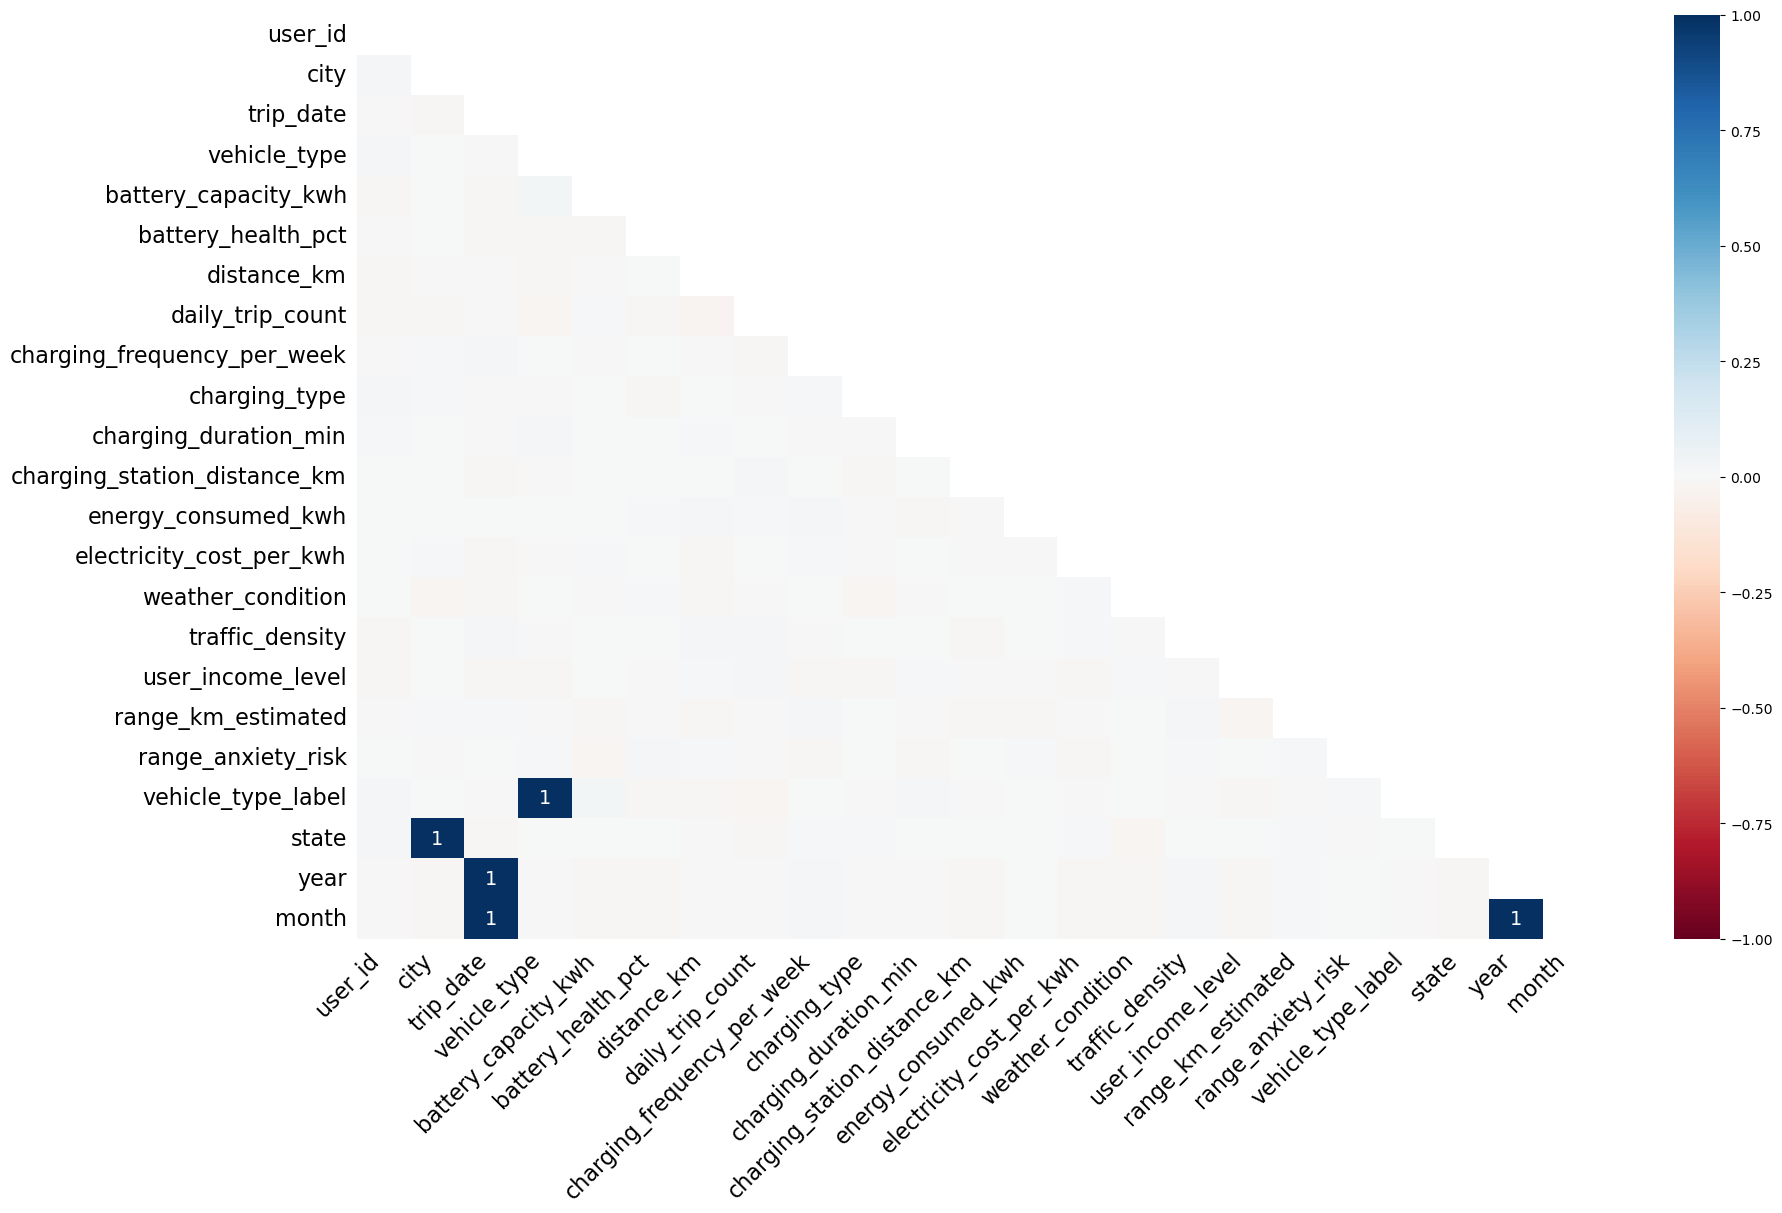

In [12]:
# Missing value correlation heatmap

msno.heatmap(df)

plt.show()

In [13]:
# Rows containing missing values

missing_rows = df[df.isnull().any(axis=1)]

missing_rows.head()

,user_id,city,trip_date,vehicle_type,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_type,charging_duration_min,charging_station_distance_km,energy_consumed_kwh,electricity_cost_per_kwh,weather_condition,traffic_density,user_income_level,range_km_estimated,range_anxiety_risk,vehicle_type_label,state,year,month
0,0f043e7d-c3b7-4478-9566-18494d053204,Mumbai,2026-03-04,2W,3.25,78.31,34.72,2.0,7.0,public_fast,55.32,NaN,6.34,9.27,rainy,0.416,low,17.54,1.0,Two-Wheeler,Maharashtra,2026.0,3.0
1,8507eade-6ee7-4c2d-80b1-eacc566a7cb2,Chennai,2026-08-03,4W,37.14,74.38,1.00,3.0,6.0,home,348.99,3.08,NaN,7.98,NaN,0.266,low,189.43,1.0,Four-Wheeler,Tamil Nadu,2026.0,8.0
4,9ca94273-0df4-48cb-be60-af643dc606f9,Bangalore,2023-09-28,2W,3.16,86.07,NaN,2.0,4.0,home,361.86,0.80,NaN,8.93,humid,0.166,low,18.97,0.0,Two-Wheeler,Karnataka,2023.0,9.0
6,2f91d5e0-b3e1-466c-82c0-f6356d1d1767,Mumbai,2023-03-31,3W,8.09,86.50,26.38,3.0,2.0,public_slow,171.21,0.68,3.68,8.36,humid,0.547,middle,NaN,0.0,Three-Wheeler,Maharashtra,2023.0,3.0
7,7c380a65-b3f6-45e4-8f84-b5261e06009c,Chennai,2019-07-07,2W,3.13,NaN,45.58,3.0,2.0,public_fast,53.81,3.94,7.91,6.67,clear,0.257,high,18.77,1.0,Two-Wheeler,Tamil Nadu,2019.0,7.0


In [14]:
# Shape of rows with missing values

missing_rows.shape

(4800, 23)

In [15]:
# Count missing values per row

missing_rows.isnull().sum(axis=1).value_counts()

1    3040
2    1070
3     461
4     173
5      47
6       9
Name: count, dtype: int64

In [16]:
# Completely empty rows

df[df.isnull().all(axis=1)]

,user_id,city,trip_date,vehicle_type,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_type,charging_duration_min,charging_station_distance_km,energy_consumed_kwh,electricity_cost_per_kwh,weather_condition,traffic_density,user_income_level,range_km_estimated,range_anxiety_risk,vehicle_type_label,state,year,month


In [17]:
# Separate numerical and categorical columns

numeric_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['battery_capacity_kwh', 'battery_health_pct', 'distance_km',
       'daily_trip_count', 'charging_frequency_per_week',
       'charging_duration_min', 'charging_station_distance_km',
       'energy_consumed_kwh', 'electricity_cost_per_kwh', 'traffic_density',
       'range_km_estimated', 'range_anxiety_risk', 'year', 'month'],
      dtype='object')

Categorical Columns:
Index(['user_id', 'city', 'trip_date', 'vehicle_type', 'charging_type',
       'weather_condition', 'user_income_level', 'vehicle_type_label',
       'state'],
      dtype='object')


In [18]:
# Fill numerical missing values with median

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [19]:
# Fill categorical missing values with mode

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [20]:
# Verify missing values

df.isnull().sum()

user_id                         0
city                            0
trip_date                       0
vehicle_type                    0
battery_capacity_kwh            0
battery_health_pct              0
distance_km                     0
daily_trip_count                0
charging_frequency_per_week     0
charging_type                   0
charging_duration_min           0
charging_station_distance_km    0
energy_consumed_kwh             0
electricity_cost_per_kwh        0
weather_condition               0
traffic_density                 0
user_income_level               0
range_km_estimated              0
range_anxiety_risk              0
vehicle_type_label              0
state                           0
year                            0
month                           0
dtype: int64

In [21]:
# Save cleaned dataset

df.to_csv('D:/Project-04/data/cleaned/ev_cleaned_v1.csv', 
index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [61]:
# Load cleaned dataset

df = pd.read_csv('D:/Project-04/data/cleaned/ev_cleaned_v1.csv')

print("Cleaned Dataset Loaded")

Cleaned Dataset Loaded


In [62]:
# Numerical statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_capacity_kwh,10939.0,11.733338,14.313513,1.13,3.010,4.270,8.850,55.910
battery_health_pct,10939.0,89.384754,8.431580,62.06,83.230,89.310,95.520,116.950
distance_km,10939.0,26.305385,16.774207,1.00,15.310,25.270,35.335,187.550
daily_trip_count,10939.0,2.502514,0.982973,1.00,2.000,2.000,3.000,6.000
charging_frequency_per_week,10939.0,3.286224,1.452762,1.00,2.000,3.000,4.000,8.000
charging_duration_min,10939.0,179.657059,105.110807,-16.34,74.860,178.470,257.405,497.270
charging_station_distance_km,10939.0,1.969730,1.927953,0.00,0.610,1.390,2.680,17.790
energy_consumed_kwh,10939.0,4.337997,2.571607,0.11,2.505,4.160,5.960,19.830
electricity_cost_per_kwh,10939.0,7.752901,1.505380,2.38,6.680,7.760,8.830,13.090
traffic_density,10939.0,0.286272,0.157810,0.00,0.165,0.265,0.389,0.902


In [63]:
# Skewness analysis

skewness = df.skew(numeric_only=True)

skewness.sort_values(ascending=False)

charging_station_distance_km    1.949887
distance_km                     1.727014
range_km_estimated              1.543963
battery_capacity_kwh            1.524847
range_anxiety_risk              1.236246
traffic_density                 0.608820
energy_consumed_kwh             0.552687
charging_duration_min           0.318903
daily_trip_count                0.291347
charging_frequency_per_week     0.205848
battery_health_pct              0.020679
electricity_cost_per_kwh       -0.013530
year                           -0.023381
month                          -0.034092
dtype: float64

| Skewness Value | Meaning             |
| -------------- | ------------------- |
| ~0             | Normal distribution |
| >1             | Highly right skewed |
| <-1            | Highly left skewed  |


In [64]:
# Kurtosis analysis

kurtosis = df.kurt(numeric_only=True)

kurtosis.sort_values(ascending=False)

distance_km                     9.192868
charging_station_distance_km    5.429192
range_km_estimated              0.699970
battery_capacity_kwh            0.600453
energy_consumed_kwh             0.475243
traffic_density                -0.058205
electricity_cost_per_kwh       -0.318271
daily_trip_count               -0.359510
range_anxiety_risk             -0.471783
battery_health_pct             -0.472437
charging_frequency_per_week    -0.608135
charging_duration_min          -0.873652
month                          -1.144242
year                           -1.189125
dtype: float64

| Kurtosis      | Meaning           |
| ------------- | ----------------- |
| ~0            | Normal tails      |
| High positive | Extreme outliers  |
| Negative      | Flat distribution |


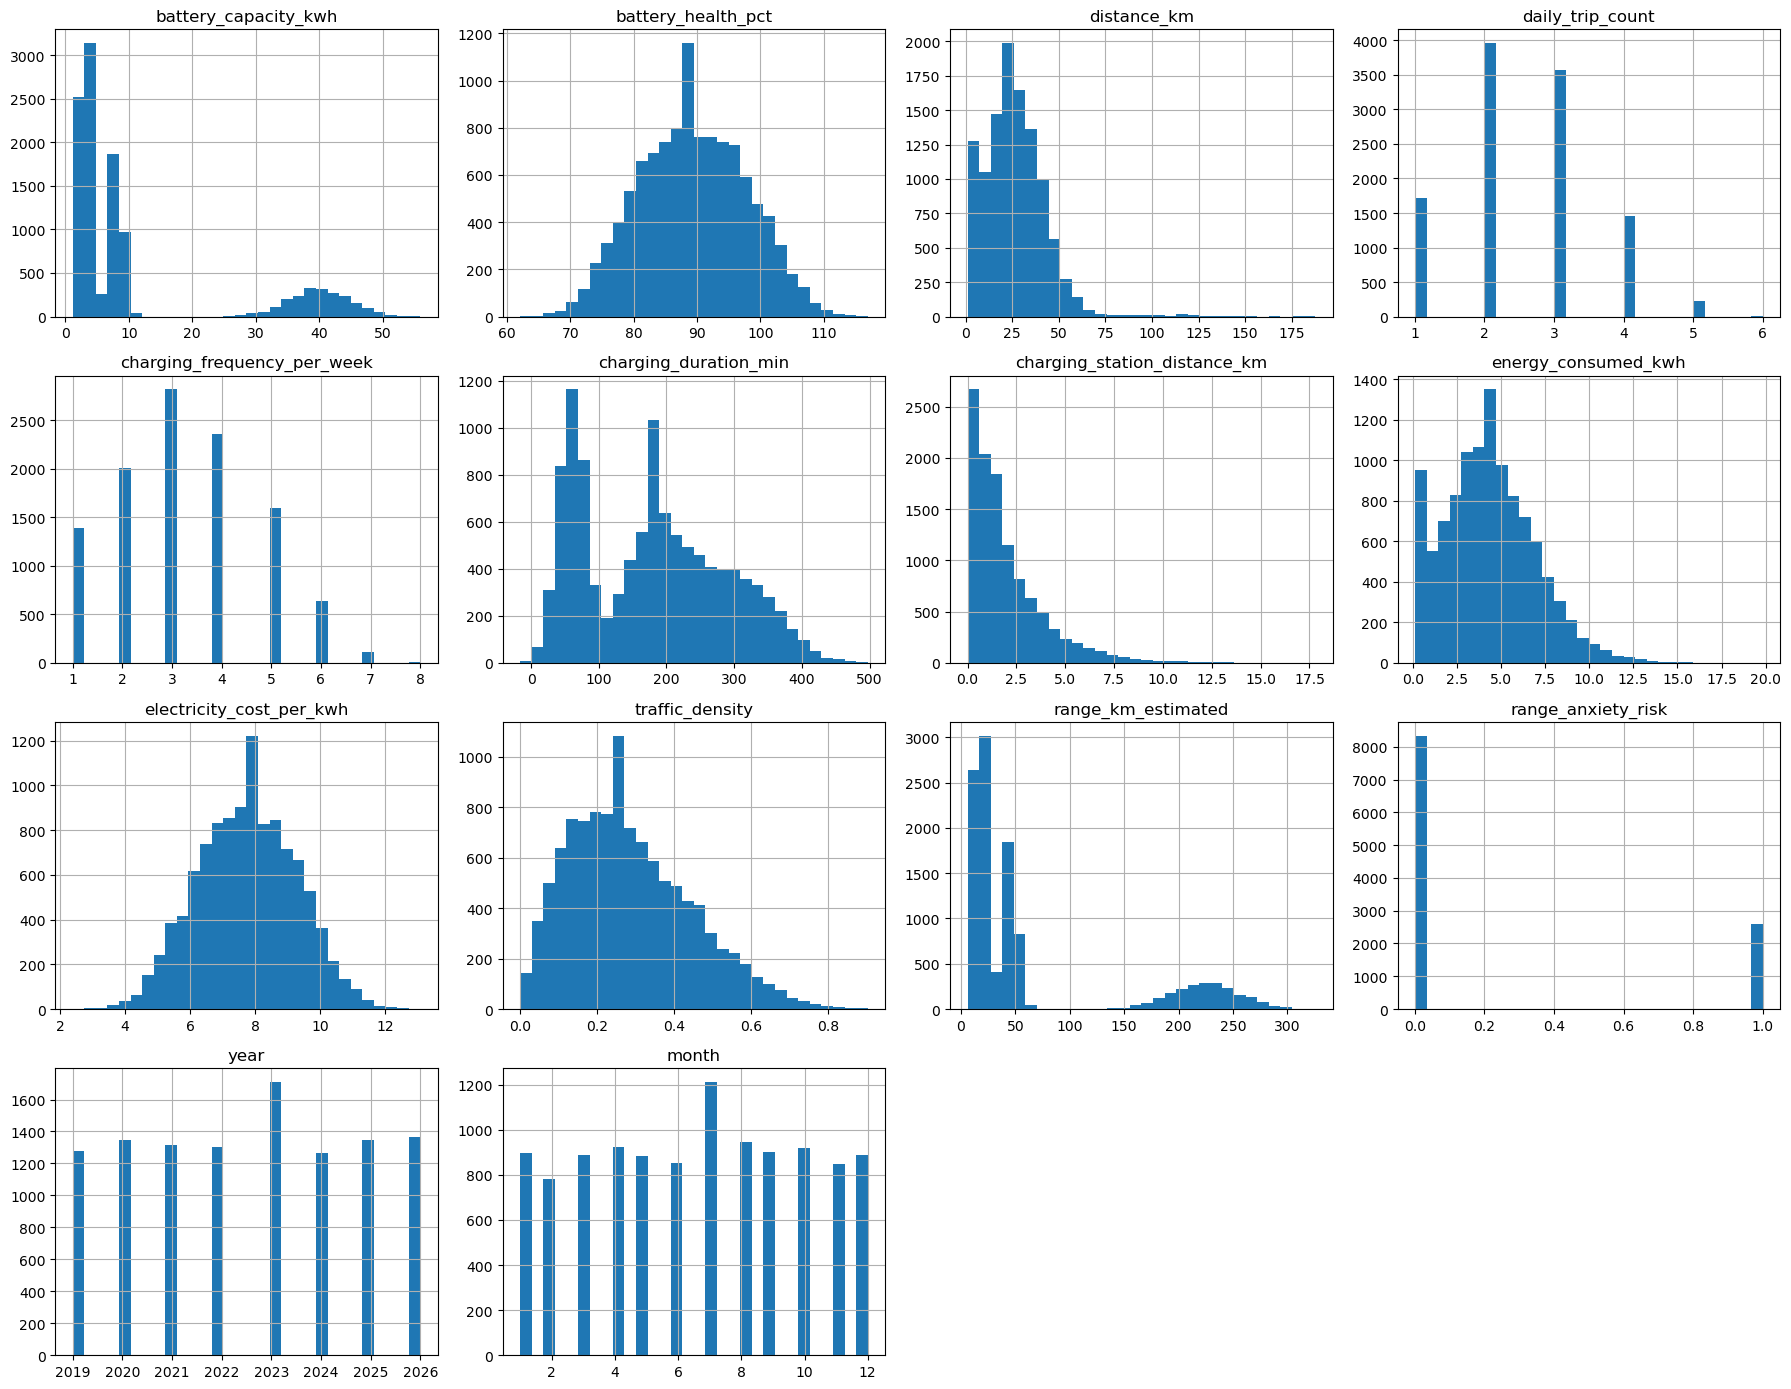

In [65]:
# Numerical distributions

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(18, 14),
    bins=30
)

plt.tight_layout()
plt.show()

What We Observe Here

We want to detect:

normal distributions
skewed distributions
bimodal patterns
unusual spikes
EV operational patterns

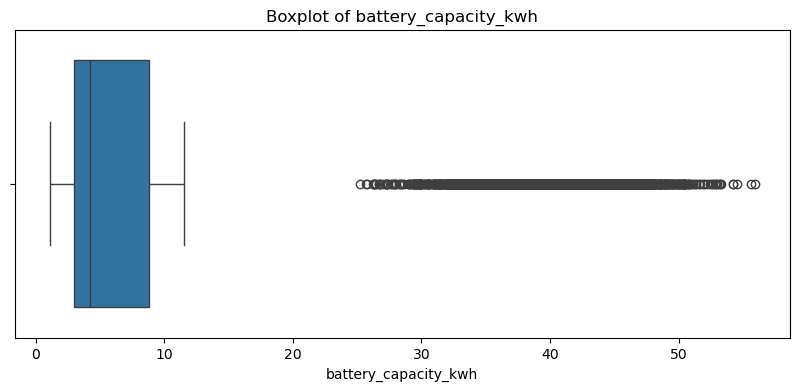

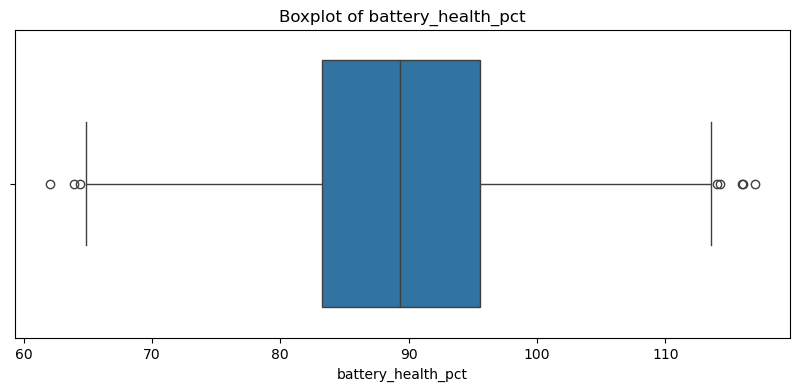

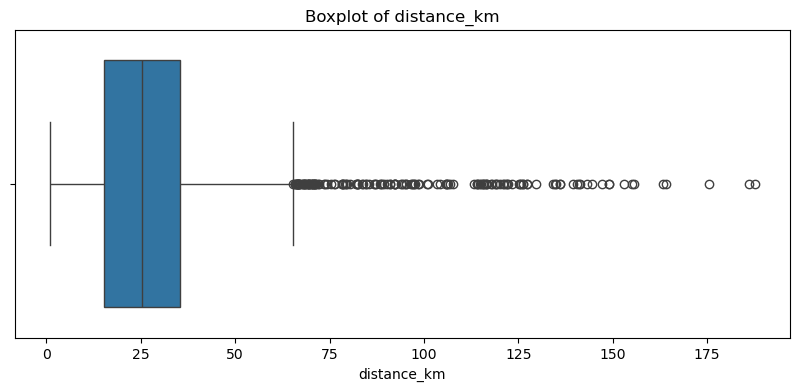

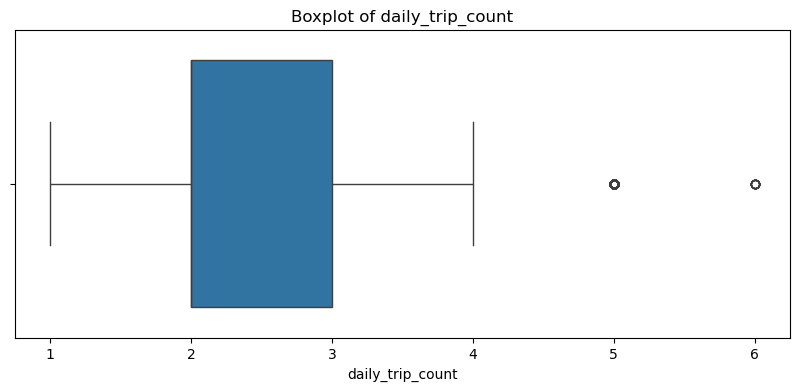

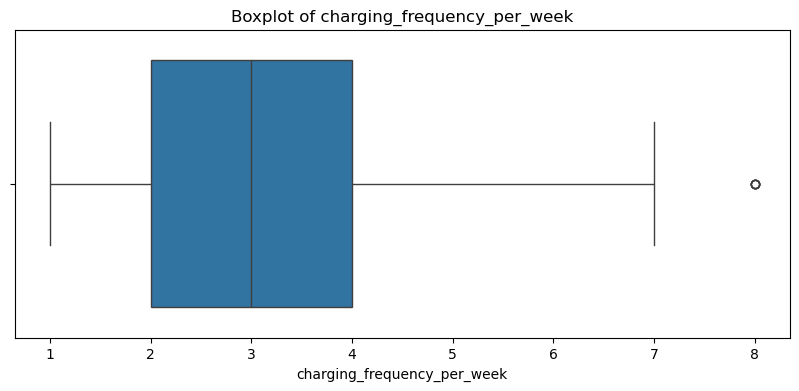

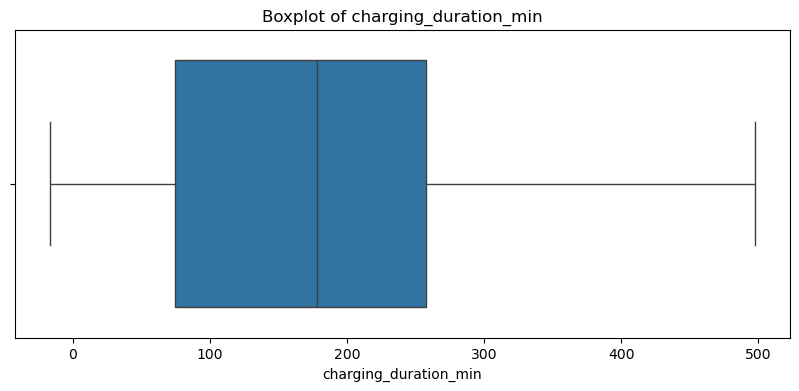

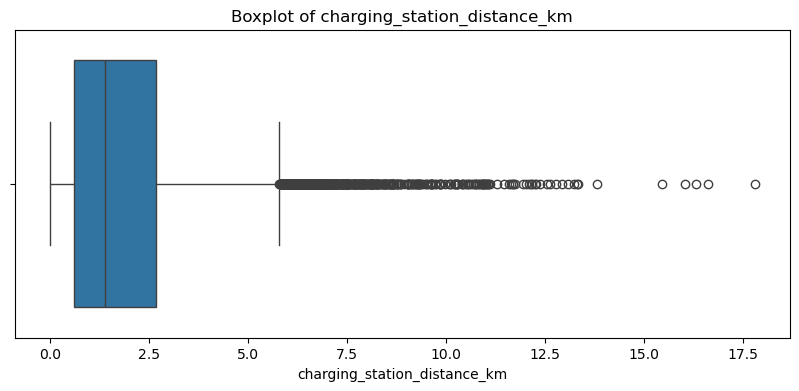

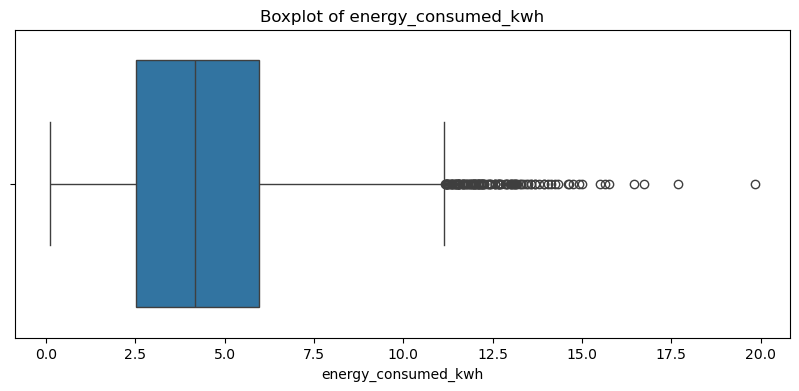

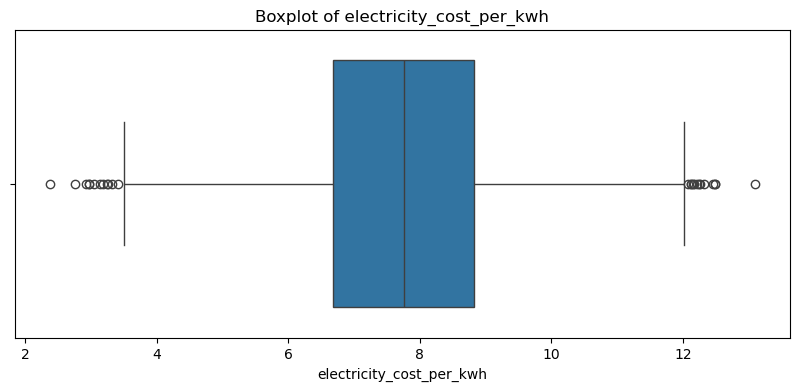

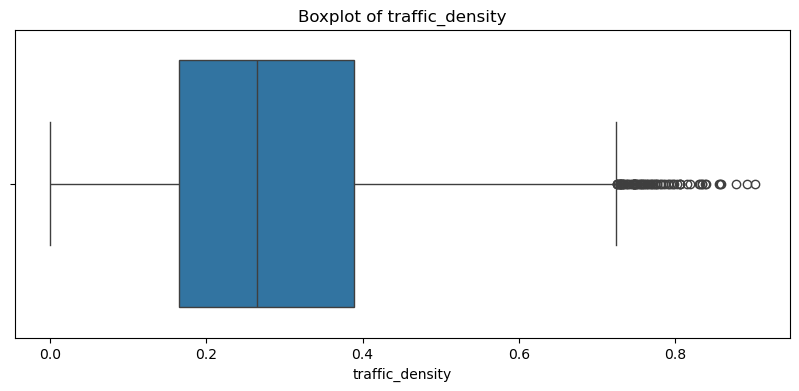

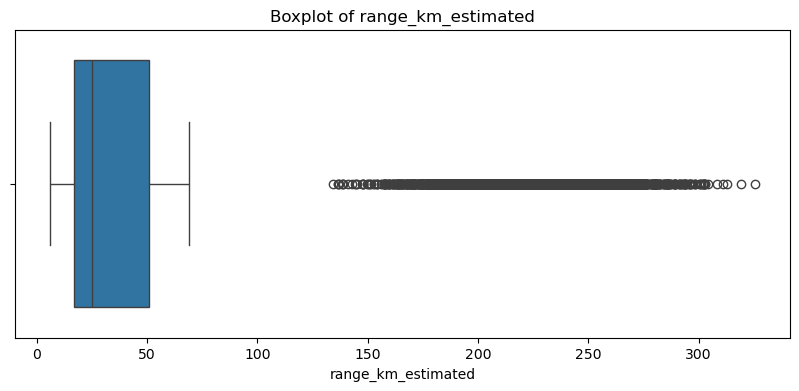

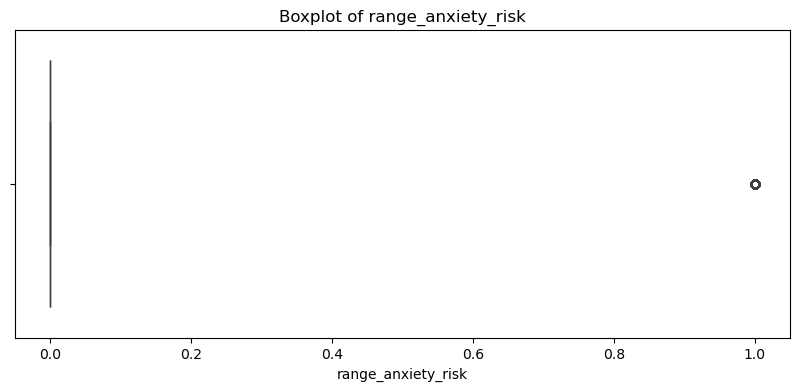

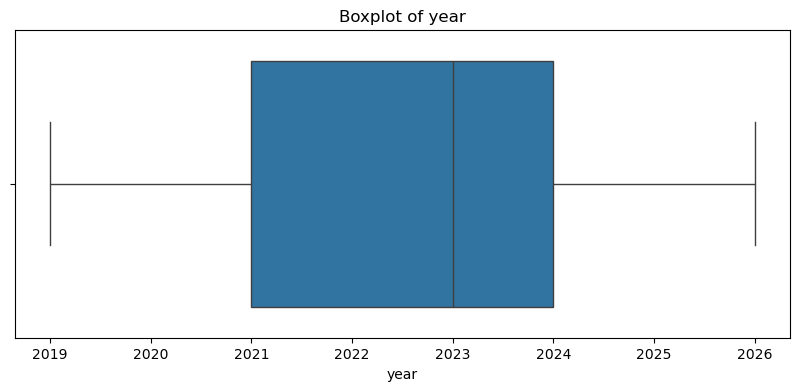

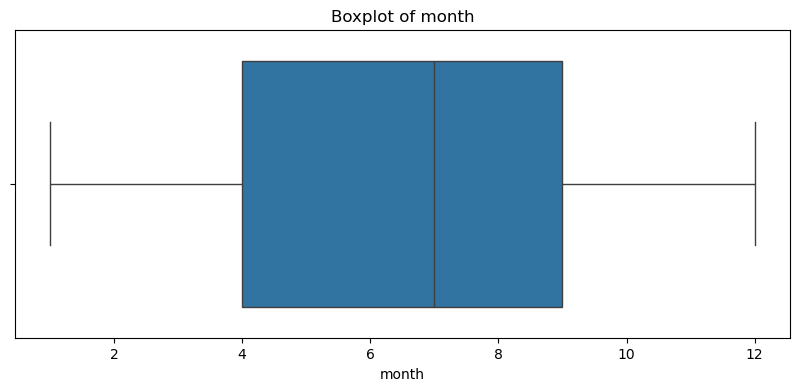

In [66]:
# Boxplots for numerical columns

for col in numeric_cols:
    
    plt.figure(figsize=(10,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

What We Look For

Boxplots reveal:

extreme EV users
abnormal charging durations
unusual energy consumption
possible data-entry issues

In [67]:
# Categorical columns

categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['user_id', 'city', 'trip_date', 'vehicle_type', 'charging_type',
       'weather_condition', 'user_income_level', 'vehicle_type_label',
       'state'],
      dtype='object')

In [68]:
# Frequency distributions

for col in categorical_cols:
    
    print(f"\n===== {col} =====")
    
    print(df[col].value_counts())


===== user_id =====
user_id
0003d09b-548a-483a-b6f5-a8aac355a42b    329
0f043e7d-c3b7-4478-9566-18494d053204      1
18821089-438c-4bba-8924-a44ada5780de      1
dbd30172-cdff-4a57-94a4-c4c232c441b9      1
2c864b3e-6fc7-432a-8602-f8c4dc3520c8      1
                                       ... 
c75bd412-ac5e-4af4-b2f8-afaf47d6cb16      1
6e32b214-1fea-4ced-9b0a-bcbd33bcd70c      1
000ced24-277a-437c-846a-28ef151b2d19      1
2425a7ce-9dcb-4b28-9976-875ba4e4e5bb      1
318d69a9-3d5f-403c-9c59-0351bb802cb8      1
Name: count, Length: 10611, dtype: int64

===== city =====
city
Pune         1892
Mumbai       1523
Ahmedabad    1523
Bangalore    1518
Hyderabad    1517
Chennai      1485
Delhi        1481
Name: count, dtype: int64

===== trip_date =====
trip_date
2026-10-01    341
2023-07-26     11
2023-03-09     11
2025-06-01     11
2023-05-21     10
             ... 
2025-02-27      1
2021-10-22      1
2022-12-11      1
2026-10-20      1
2025-07-01      1
Name: count, Length: 2851, dtype: int64


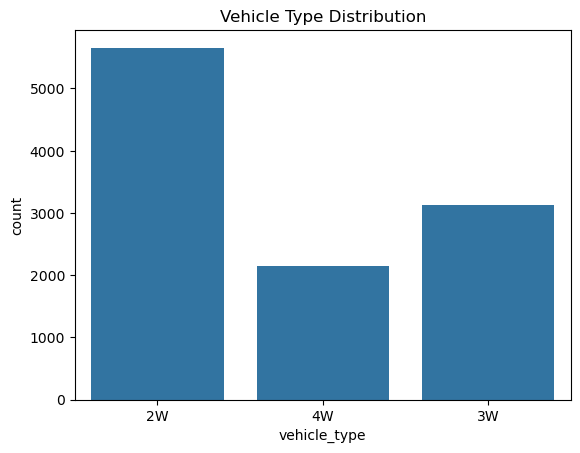

In [69]:
# Vehicle type distribution

sns.countplot(
    x='vehicle_type',
    data=df
)

plt.title("Vehicle Type Distribution")

plt.show()

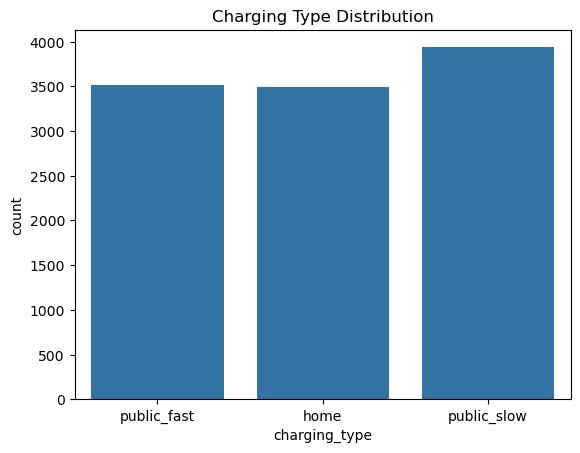

In [70]:
# charging_type distribution

sns.countplot(
    x='charging_type',
    data=df
)

plt.title("Charging Type Distribution")

plt.show()

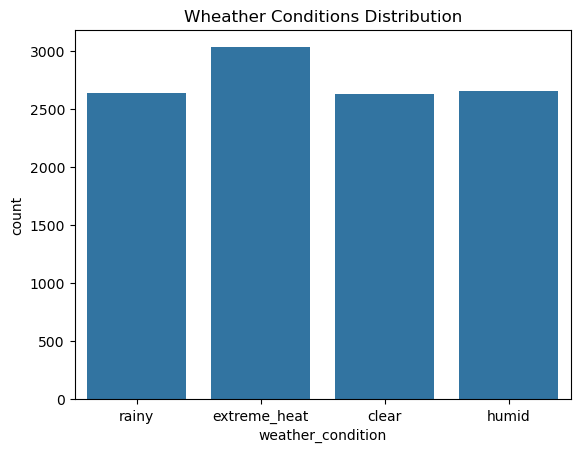

In [71]:
# weather_condition distribution

sns.countplot(
    x='weather_condition',
    data=df
)

plt.title("Wheather Conditions Distribution")

plt.show()

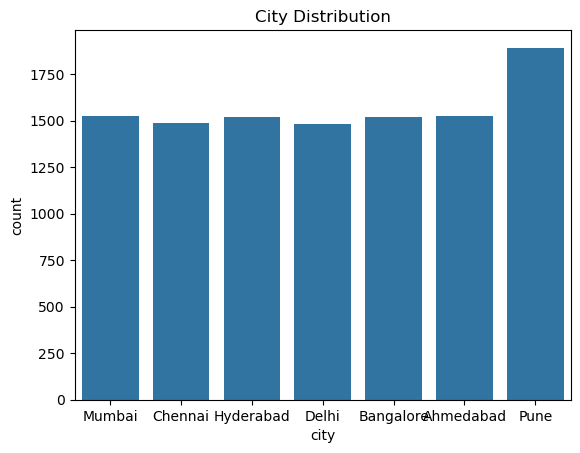

In [72]:
# City type distribution

sns.countplot(
    x='city',
    data=df
)

plt.title("City Distribution")

plt.show()

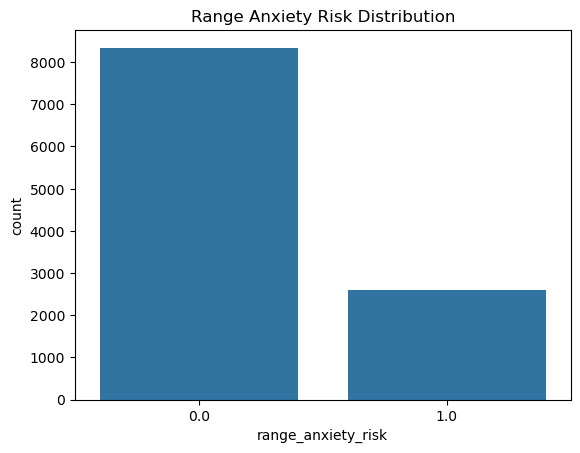

In [73]:
# range_anxiety_risk distribution

sns.countplot(
    x='range_anxiety_risk',
    data=df
)

plt.title("Range Anxiety Risk Distribution")

plt.show()

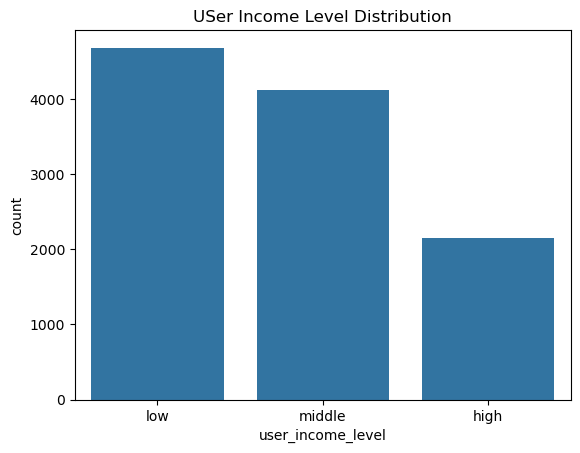

In [74]:

# user_income_level distribution

sns.countplot(
    x='user_income_level',
    data=df
)

plt.title("USer Income Level Distribution")

plt.show()

In [75]:
# Correlation matrix

corr_matrix = df.corr(numeric_only=True)

corr_matrix

,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_duration_min,charging_station_distance_km,energy_consumed_kwh,electricity_cost_per_kwh,traffic_density,range_km_estimated,range_anxiety_risk,year,month
battery_capacity_kwh,1.000000,0.005377,0.002685,0.006424,-0.024058,0.000957,-0.000153,0.003824,-0.013716,0.004938,0.955269,-0.217928,-0.010045,0.025039
battery_health_pct,0.005377,1.000000,-0.000517,-0.004317,-0.591301,-0.001987,0.014298,-0.005377,-0.590182,0.004921,0.005908,-0.296109,-0.782372,-0.008607
distance_km,0.002685,-0.000517,1.000000,0.011584,-0.001772,0.015915,-0.012886,0.799304,0.005195,-0.000944,0.004403,0.154490,-0.002376,0.008796
daily_trip_count,0.006424,-0.004317,0.011584,1.000000,-0.003097,-0.007017,0.003075,0.010835,0.002997,0.016977,0.007488,-0.001863,0.007297,-0.005895
charging_frequency_per_week,-0.024058,-0.591301,-0.001772,-0.003097,1.000000,-0.002246,-0.002028,0.006687,0.543735,0.002594,-0.025860,0.395117,0.723237,-0.002544
charging_duration_min,0.000957,-0.001987,0.015915,-0.007017,-0.002246,1.000000,-0.004943,0.007853,-0.005645,-0.013624,0.000366,-0.007809,0.002112,-0.005838
charging_station_distance_km,-0.000153,0.014298,-0.012886,0.003075,-0.002028,-0.004943,1.000000,-0.011053,-0.007467,-0.000913,0.003045,0.365141,-0.011302,-0.009320
energy_consumed_kwh,0.003824,-0.005377,0.799304,0.010835,0.006687,0.007853,-0.011053,1.000000,0.006734,0.002189,0.004250,0.166132,0.001356,0.003440
electricity_cost_per_kwh,-0.013716,-0.590182,0.005195,0.002997,0.543735,-0.005645,-0.007467,0.006734,1.000000,-0.008663,-0.014919,0.234576,0.729803,-0.004547
traffic_density,0.004938,0.004921,-0.000944,0.016977,0.002594,-0.013624,-0.000913,0.002189,-0.008663,1.000000,0.003754,0.021500,-0.000264,-0.017402


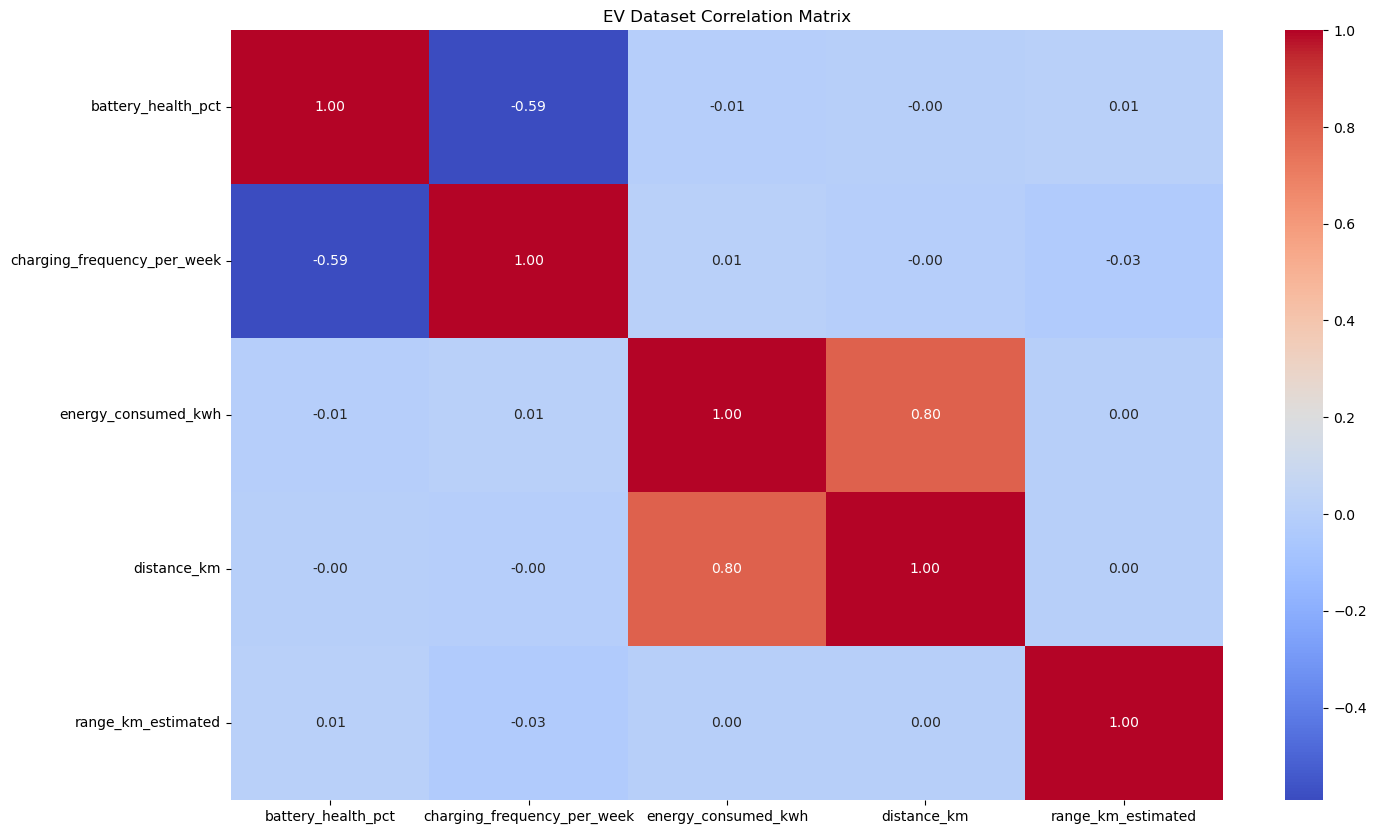

In [76]:
# Correlation heatmap

plt.figure(figsize=(16,10))

# Define selected columns
selected_cols = [
    'battery_health_pct',
    'charging_frequency_per_week',
    'energy_consumed_kwh',
    'distance_km',
    'range_km_estimated'
]

# Calculate correlation matrix and pass it as the data parameter
sns.heatmap(
    df[selected_cols].corr(),  # Added correlation matrix as the required 'data' parameter
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("EV Dataset Correlation Matrix")

plt.show()

| Relationship Type    | Meaning                             |
| -------------------- | ----------------------------------- |
| Strong Positive (+1) | Variables increase together         |
| Strong Negative (-1) | One increases while other decreases |
| Near 0               | Weak/no relationship                |


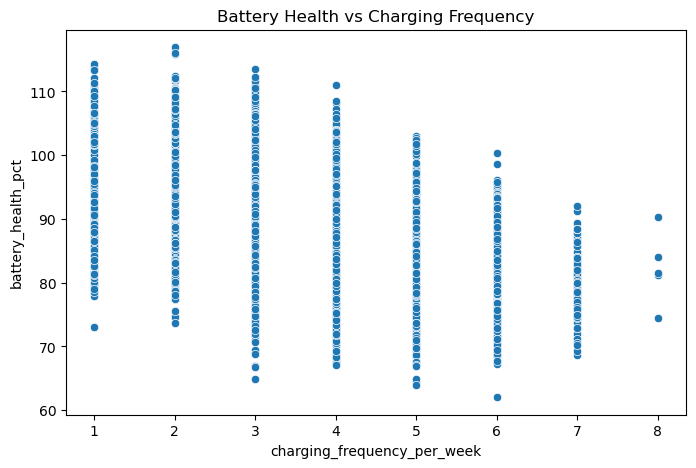

In [77]:
# Battery health vs charging frequency

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='charging_frequency_per_week',
    y='battery_health_pct',
    data=df
)

plt.title("Battery Health vs Charging Frequency")

plt.show()

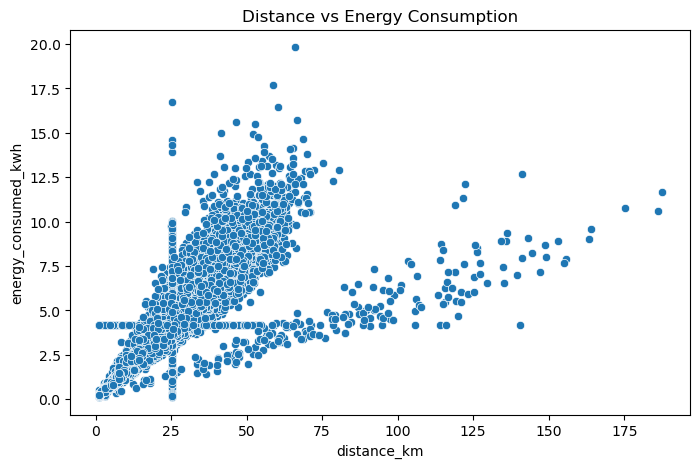

In [78]:
# Distance vs energy consumption

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='distance_km',
    y='energy_consumed_kwh',
    data=df
)

plt.title("Distance vs Energy Consumption")

plt.show()

In [79]:
print(df.columns.tolist())

['user_id', 'city', 'trip_date', 'vehicle_type', 'battery_capacity_kwh', 'battery_health_pct', 'distance_km', 'daily_trip_count', 'charging_frequency_per_week', 'charging_type', 'charging_duration_min', 'charging_station_distance_km', 'energy_consumed_kwh', 'electricity_cost_per_kwh', 'weather_condition', 'traffic_density', 'user_income_level', 'range_km_estimated', 'range_anxiety_risk', 'vehicle_type_label', 'state', 'year', 'month']


In [80]:
# Distance categories

df['distance_category'] = pd.qcut(
    df['distance_km'],
    
    q=4,
    
    labels=[
        'Short Distance',
        'Medium Distance',
        'Long Distance',
        'Extreme Distance'
    ]
)

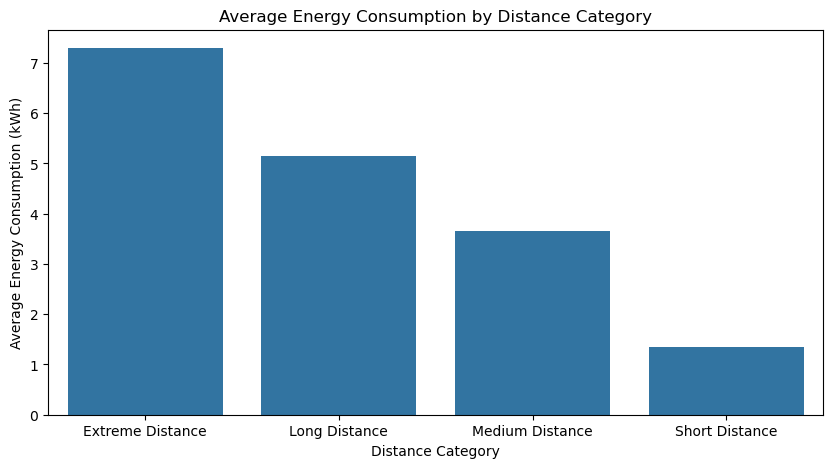

In [81]:
## Group and sort values

# Group data

distance_energy = df.groupby(
    'distance_category'
)['energy_consumed_kwh'].mean().reset_index()

# Sort ascending

distance_energy = distance_energy.sort_values(
    by='energy_consumed_kwh',
    ascending=False
)

# Create ordered list

ordered_categories = distance_energy['distance_category']

# Plot

plt.figure(figsize=(10,5))

sns.barplot(
    data=distance_energy,
    x='distance_category',
    y='energy_consumed_kwh',
    order=ordered_categories
)

plt.title("Average Energy Consumption by Distance Category")

plt.xlabel("Distance Category")

plt.ylabel("Average Energy Consumption (kWh)")

plt.show()

In [82]:
# Create battery capacity categories

df['battery_category'] = pd.qcut(
    df['battery_capacity_kwh'],
    
    q=4,
    
    labels=[
        'Small Battery',
        'Medium Battery',
        'Large Battery',
        'Ultra Battery'
    ]
)

In [83]:
# Average estimated range by battery category

battery_range = df.groupby(
    'battery_category'
)['range_km_estimated'].mean().reset_index()

In [84]:
# Sort values

battery_range = battery_range.sort_values(
    by='range_km_estimated',
    ascending=False
)

In [85]:
# Ordered categories

ordered_categories = battery_range['battery_category']

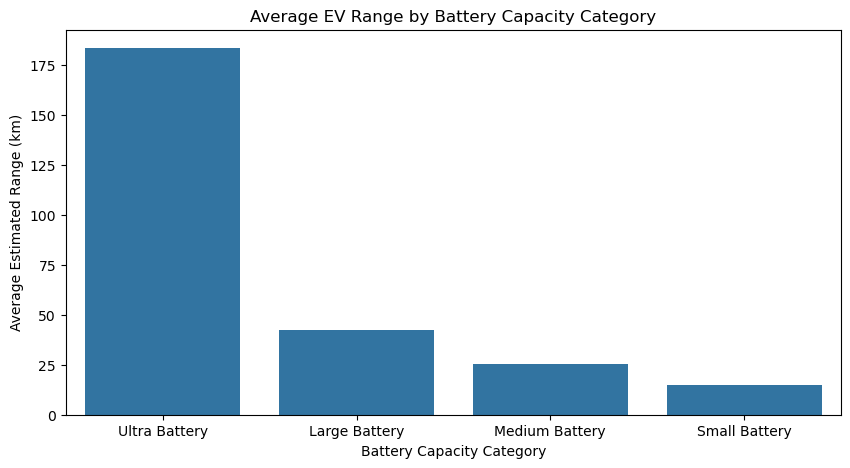

In [86]:
# Plot

plt.figure(figsize=(10,5))

sns.barplot(
    data=battery_range,
    x='battery_category',
    y='range_km_estimated',
    order=ordered_categories
)

plt.title("Average EV Range by Battery Capacity Category")

plt.xlabel("Battery Capacity Category")

plt.ylabel("Average Estimated Range (km)")

plt.show()

In [87]:
# Create charging frequency categories

df['charging_category'] = pd.qcut(
    df['charging_frequency_per_week'],
    
    q=4,
    
    labels=[
        'Low Charging',
        'Moderate Charging',
        'Frequent Charging',
        'Extreme Charging'
    ]
)

In [88]:
# Average battery health by charging category

charging_health = df.groupby(
    'charging_category'
)['battery_health_pct'].mean().reset_index()

In [89]:
# Sort values

charging_health = charging_health.sort_values(
    by='battery_health_pct',
    ascending=False
)

In [90]:
# Ordered categories

ordered_categories = charging_health['charging_category']

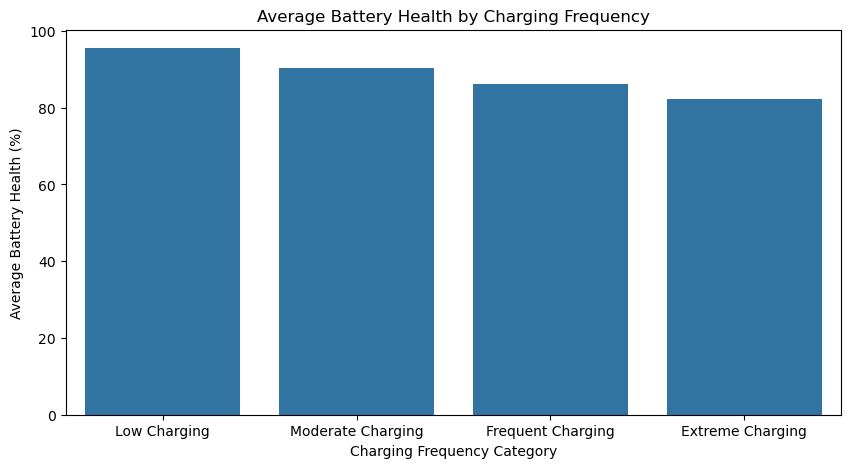

In [91]:
# Plot

plt.figure(figsize=(10,5))

sns.barplot(
    data=charging_health,
    x='charging_category',
    y='battery_health_pct',
    order=ordered_categories
)

plt.title("Average Battery Health by Charging Frequency")

plt.xlabel("Charging Frequency Category")

plt.ylabel("Average Battery Health (%)")

plt.show()

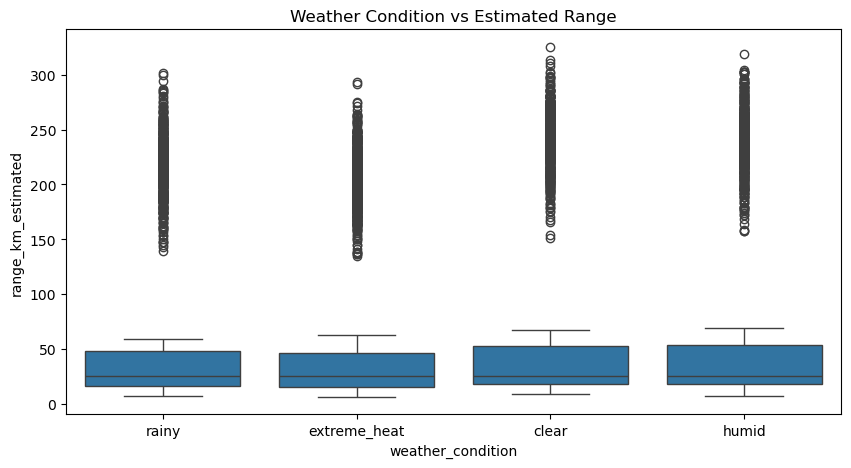

In [92]:
# Weather vs estimated range

plt.figure(figsize=(10,5))

sns.boxplot(
    x='weather_condition',
    y='range_km_estimated',
    data=df
)

plt.title("Weather Condition vs Estimated Range")

plt.show()

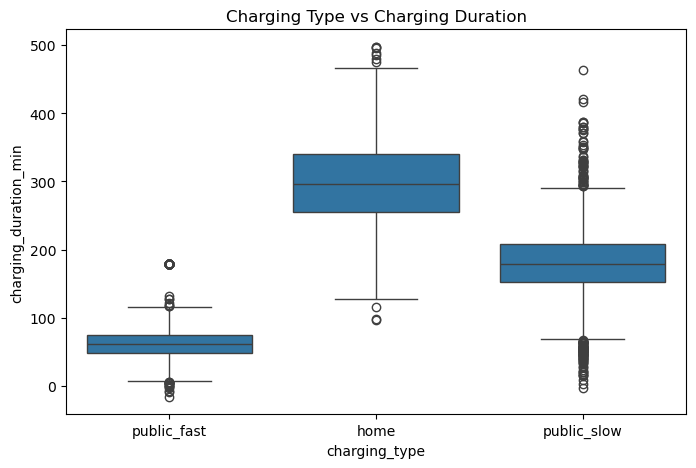

In [93]:
# Charging type vs charging duration

plt.figure(figsize=(8,5))

sns.boxplot(
    x='charging_type',
    y='charging_duration_min',
    data=df
)

plt.title("Charging Type vs Charging Duration")

plt.show()

In [94]:
# Create efficiency metric

df['km_per_kwh'] = (
    df['distance_km']
    /
    df['energy_consumed_kwh']
)

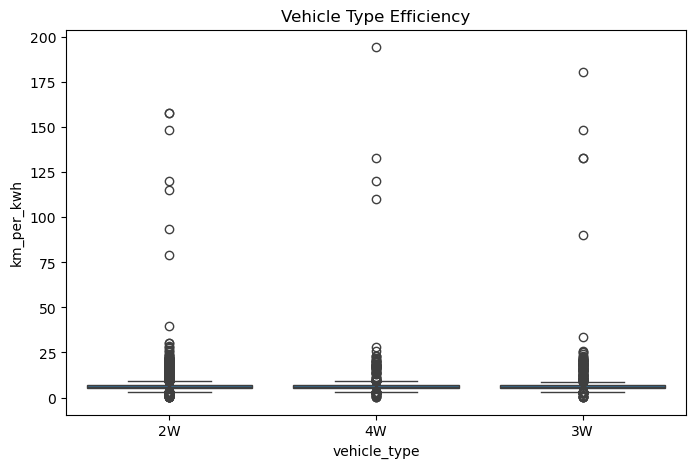

In [95]:
# Vehicle efficiency comparison

plt.figure(figsize=(8,5))

sns.boxplot(
    x='vehicle_type',
    y='km_per_kwh',
    data=df
)

plt.title("Vehicle Type Efficiency")

plt.show()

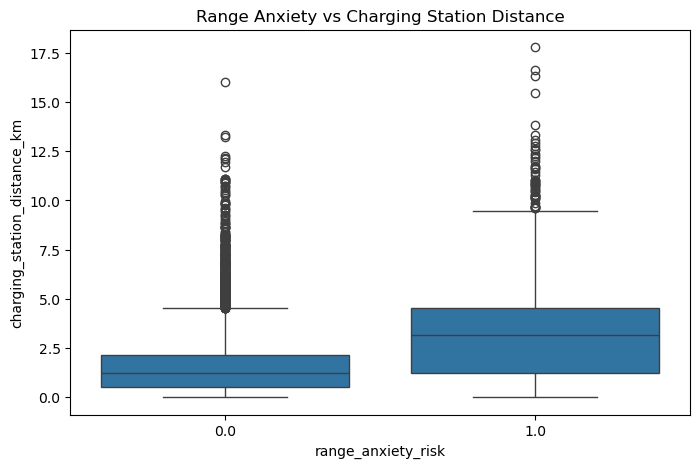

In [96]:
# Range anxiety by charging station distance

plt.figure(figsize=(8,5))

sns.boxplot(
    x='range_anxiety_risk',
    y='charging_station_distance_km',
    data=df
)

plt.title("Range Anxiety vs Charging Station Distance")

plt.show()

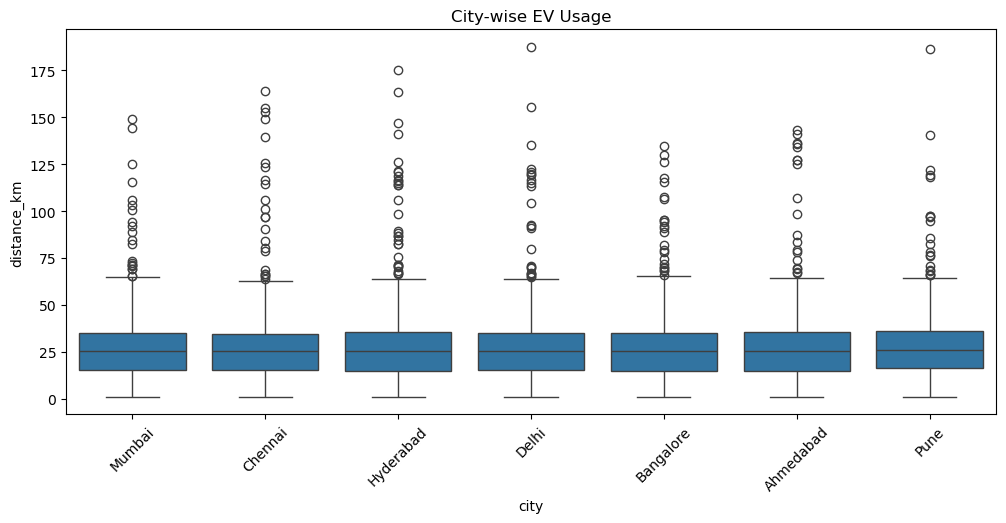

In [97]:
# City-wise distance analysis

plt.figure(figsize=(12,5))

sns.boxplot(
    x='city',
    y='distance_km',
    data=df
)

plt.title("City-wise EV Usage")

plt.xticks(rotation=45)

plt.show()